In [15]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [18]:
import sys
sys.path.append("..")

In [19]:
import sys
import os
import mmap

import zernike_functions

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import sys
sys.path.append("..")

In [21]:
nptypes={'double':np.float64, 'uint16_t':np.uint16,'uint8_t':np.uint8,  'uint64_t':np.uint64}
def shmem_item(shmem1,layout,varname,offset2=0):
    item_info=layout[1][varname]
    data=np.frombuffer(shmem1, dtype=nptypes[item_info['type']],
                       count=item_info['num_elements'], offset=item_info['bytenum_current']+offset2)
    if len(data)==1:
        data=data[0]
    return data

def shmem_write(shmem1,layout,varname,data):
    item_info=layout[1][varname]
    bytez =np.array(data, dtype=nptypes[item_info['type']]).tobytes()   
    offset=item_info['bytenum_current']
    shmem1[offset : offset + len(bytez)] = bytez

class NW_shmem:
    def __init__(self,mem,layout):
        self.mem = mem
        self.layout = layout

    def item(self,name,offset2=0):
        return shmem_item(self.mem, self.layout, name, offset2=offset2)

    def write(self,name,data):
        return shmem_write(self.mem, self.layout, name, data)

    def get_fields(self):
        return list( self.layout[1].keys() )
 

In [22]:
from multiprocessing import shared_memory

sys.path.append("..")
import extract_memory
layout=extract_memory.get_header_format('../memory_layout.h')
NAME='NW_SRC0_HDR'
shmem_main = shared_memory.SharedMemory(name=NAME)

#layout_log=extract_memory.get_header_format('../layout_log.h')
#NAME='NW_LOG'
#shm_log = shared_memory.SharedMemory(name=NAME, size=1024*1024*16)
# TODO: Get size correctly. From the main memory maybe?
#log0 = NW_shmem(shm_log.buf,layout_log)

layoutb=extract_memory.get_header_format('../layout_boxes.h')
shmem_boxes = shared_memory.SharedMemory(name="NW_BUFFER_BOXES", size=1024*1024*1024)
buf_boxes=shmem_boxes.buf
#test


In [23]:
# New way:
boxmem = NW_shmem(buf_boxes,layoutb)
num_boxes=boxmem.item("num_boxes")


# OLD WAY:

centroid_x=shmem_item( buf_boxes, layoutb, 'centroid_x')[0:num_boxes]
centroid_y=shmem_item( buf_boxes, layoutb, 'centroid_y')[0:num_boxes]
reference_x=shmem_item( buf_boxes, layoutb, 'reference_x')[0:num_boxes]
reference_y=shmem_item( buf_boxes, layoutb, 'reference_y')[0:num_boxes]


mem0 = NW_shmem(shmem_main.buf,layout)

print( num_boxes, centroid_x[10],  centroid_y[10] )

421 474.28632965468137 248.03495906016374


In [36]:
# START HERE to RELOAD
num_boxes=shmem_item( buf_boxes, layoutb, 'num_boxes')

Z_TERMS = 65

# Make sure to do "save centroids+Zernikes from nextwave UI to save these files:"
mirs=np.loadtxt("../mirror_voltages.txt")
infi=np.load('../influ.npy')
zterms_full=np.load("../zterms_full.npy")
zterms_20 =np.load("../zterms_20.npy")
zt_inv2 = pinv(zterms_full[0:Z_TERMS] )

#inf_full = np.loadtxt(
#    "c:/MiniWave/MiniWaveConfiguration/InfluenceMatrix_ALPAO_7.5mm_new.txt")

inf_full = np.load("../infl_reduced.npy")

print( inf_full.shape, infi.shape )

(97, 842) (842, 97)


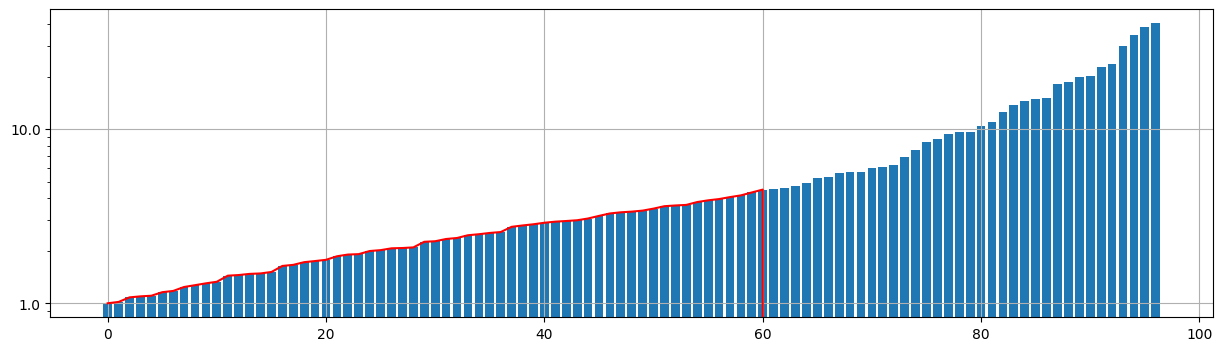

In [342]:
DESIRED_MODES=61

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter()
formatter.set_scientific(False) # Example: disable scientific notation
formatter.set_useOffset(False) # Example: disable offset

#if len(self.acts_outside)>0:
#    self.influence[self.acts_outside,:] = 0 # Zero them out, if any
U, s, V = np.linalg.svd(inf_full, full_matrices=True)
s_recip = 1/s
plt.figure(figsize=(15,4))
plt.bar(np.arange(len(s_recip)), s_recip/s_recip[0] )
plt.semilogy()
plt.gca().yaxis.set_major_formatter(formatter)
plt.grid()

if DESIRED_MODES < len(s):
    s_recip[DESIRED_MODES:] = 0
    
s_recip[ s<1e-10 ] = 0 # Set any tinies (or 0) to zero

influence_inv = ( (U * s_recip) @ V[0:97,:] ).T
#print( max_boxes, len(valid_boxes), self.influence.shape, s.max(), valid_boxes[0:10], RR.shape )

infi_prev = influence_inv.copy()
plt.plot( s_recip/s_recip[0], 'r-')

In [332]:
# Use the fancy new one
influence_inv=np.load("inverse.npy").T

In [333]:
# Get Kaitlyn's Zs
import pandas

df_k = pandas.read_csv('./dataset.csv')
df_k

Z_k = np.array( df_k.iloc[0,6:].to_numpy(), dtype='float64' )
Z_k_ho = Z_k.copy()
Z_k_ho[0:5]=0
#plt.plot( zernikes, 'o-' )

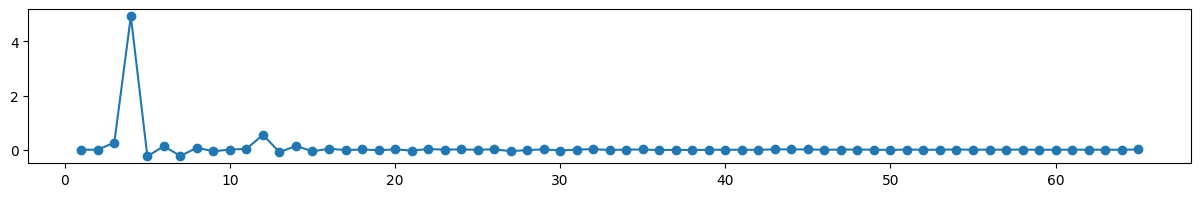

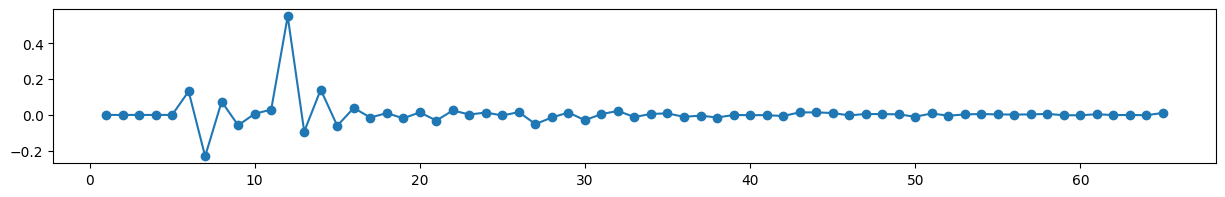

In [334]:
plt.figure(figsize=(15,2))
plt.plot( np.arange(len(Z_k))+1, Z_k, 'o-' )

plt.figure(figsize=(15,2))
plt.plot( np.arange(len(Z_k_ho))+1, Z_k_ho, 'o-' )

In [19]:
# 12 345 6789 10_11_12_13_14

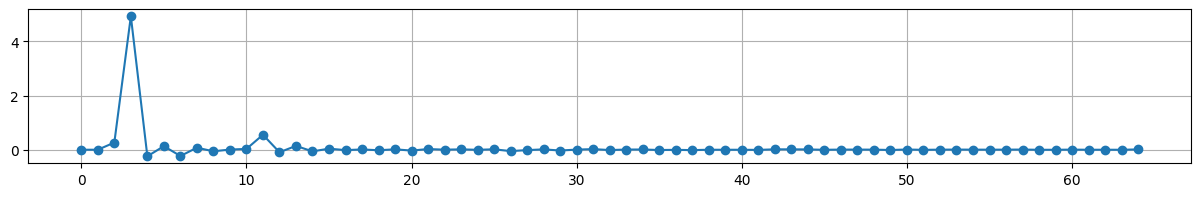

In [15]:
plt.figure(figsize=(15,2))
plt.plot( np.arange(len(Z_k)), Z_k, 'o-' )
plt.grid()

In [16]:
# Get new "best mirror" / flat wavefront  / "
mirs_model_best=boxmem.item("mirror_voltages")[0:97].copy()
slopes_desired = np.matmul(mirs_model_best,inf_full) / (boxmem.item("pixel_um")/boxmem.item("focal_um") )
slopes_system = slopes_desired.copy()  #np.vstack( (slopes_desired[halfway:],slopes_desired[:halfway]) ).T.flatten()*1000
halfway = len(slopes_system)//2
slopes_system[:halfway] = slopes_desired[1::2]
slopes_system[halfway:] = slopes_desired[0::2]

In [43]:
import functions_grid

In [61]:
rx_sorted=np.unique( reference_x )
ry_sorted=np.unique( reference_y )

In [173]:
%load_ext autoreload
%autoreload 2
import functions_grid

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [210]:
def build_dense(arrx,arry):
    rx_sorted=np.unique( arrx )
    ry_sorted=np.unique( arry )
    
    r=np.ceil( np.sqrt( len(arrx)/3.14 ) )
    diam = int( (r-1)*2+1 )
    print( diam, diam*diam, len(arrx) )
    
    to_dense_map=np.zeros( (diam,diam), dtype='int')-1
    for nref,rx1 in enumerate(arrx):
        nx=np.where( (rx_sorted == arrx[nref] ) )
        ny=np.where( (ry_sorted == arry[nref] ) )
    
        to_dense_map[ny,nx] = int(nref)

    return to_dense_map

In [212]:
xact,yact=functions_grid.idxs_sparse(97)

In [218]:
to_dense_map=build_dense(xact,yact)
to_dense_map

11 121 97


array([[-1, -1, -1,  0,  1,  2,  3,  4, -1, -1, -1],
       [-1, -1,  5,  6,  7,  8,  9, 10, 11, -1, -1],
       [-1, 12, 13, 14, 15, 16, 17, 18, 19, 20, -1],
       [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
       [32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42],
       [43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53],
       [54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64],
       [65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75],
       [-1, 76, 77, 78, 79, 80, 81, 82, 83, 84, -1],
       [-1, -1, 85, 86, 87, 88, 89, 90, 91, -1, -1],
       [-1, -1, -1, 92, 93, 94, 95, 96, -1, -1, -1]])

In [236]:
def idx_to_yx(idx):
    matches=np.where( (idx == to_dense_map ))
    return matches[0][0],matches[1][0]
def yx_to_idx(y,x):
    return to_dense_map[y,x]

In [237]:
idx_to_xy(0)

(np.int64(0), np.int64(3))

In [240]:
yx_to_idx(0,2)

np.int64(-1)

In [222]:
to_dense_map[7,9],to_dense_map[6,9]

(np.int64(74), np.int64(63))

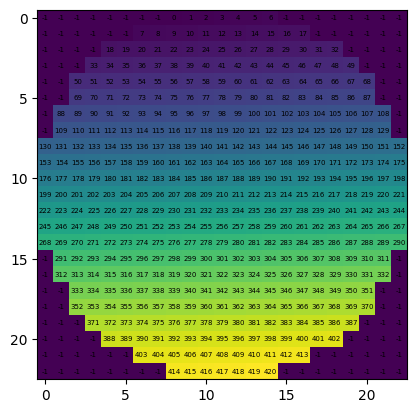

In [127]:
plt.imshow( to_dense_map)
for ny in np.arange(to_dense_map.shape[0]):
    for nx in np.arange(to_dense_map.shape[1]):
        plt.text(nx,ny,to_dense_map[ny,nx], size=5,ha='center',va='center' )

#to_dense_map

In [276]:
# For a dense 2D array:
def build_laplacianX(n_act_x, n_act_y):
    N = n_act_x * n_act_y
    L = np.zeros((N, N))
    for i in range(n_act_x):
        for j in range(n_act_y):
            idx = i * n_act_y + j
            neighbors = []
            if i > 0: neighbors.append((i-1)*n_act_y + j)
            if i < n_act_x-1: neighbors.append((i+1)*n_act_y + j)
            if j > 0: neighbors.append(i*n_act_y + (j-1))
            if j < n_act_y-1: neighbors.append(i*n_act_y + (j+1))
            L[idx, idx] = len(neighbors)
            for n in neighbors:
                L[idx, n] = -1
    return L

# For our (currently sparse) Nextwave box array:
def build_laplacian_sparse(n_act):
    N = n_act
    L = np.zeros((N, N))
    for idx in range(n_act):
        y,x=idx_to_yx(idx)
        neighbors = []
        if x > 0: neighbors.append(yx_to_idx(y,x-1))
        if x < to_dense_map.shape[1]-1: neighbors.append(yx_to_idx(y,x+1))
        if y > 0: neighbors.append(yx_to_idx(y-1,x))
        if y < to_dense_map.shape[0]-1: neighbors.append(yx_to_idx(y+1,x))
        valids=0
        for n in neighbors:
            if n==-1: continue # Not valid idx on this grid
            L[idx, n] = -1
            valids += 1
        L[idx,idx] = valids
    return L

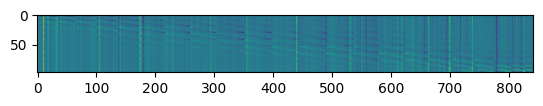

In [328]:
plt.imshow( np.load("../inverse.npy") )

In [344]:
modes=91

L=build_laplacian_sparse(97)

R=L
R_ridge = R + 1e-6 * np.eye(R.shape[0] )
QR,S=np.linalg.qr(R_ridge,mode='reduced')
S_inv=np.linalg.pinv(S)
D_w = D @ S_inv

U,sv,Vt = np.linalg.svd(D_w,full_matrices=False)
alpha=0.01
ff=sv/(sv**2+alpha)

ff[modes:] = 0
C_w = Vt.T @ np.diag(ff) @ U.T

C2=S_inv @ C_w

np.save("../inverse",C2)

In [356]:
influence_inv = C2.T.copy()

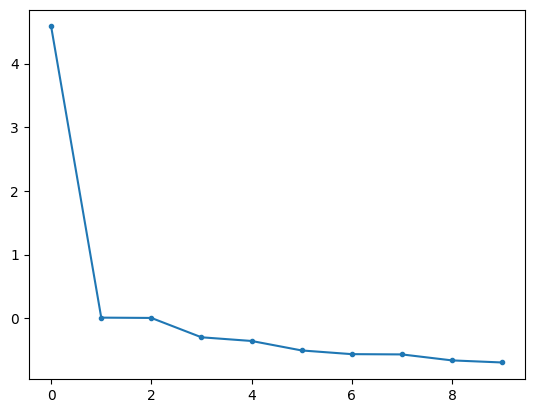

In [316]:
plt.plot( np.log10(sv)[0:10], '.-' )

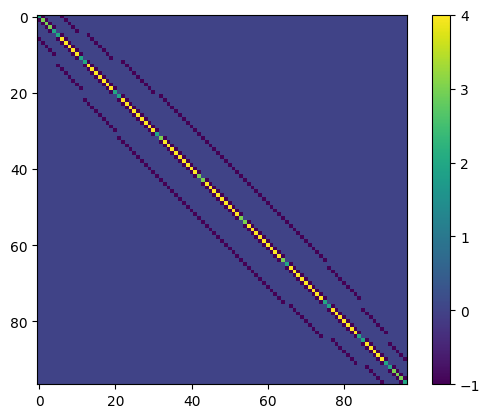

In [278]:
plt.imshow(L)
plt.colorbar()

In [350]:
# Simple method using Tikhanov
D=inf_full.T
alpha=0.01
DtD = D.T @ D
RtR = R.T @ R
C = np.linalg.inv(DtD + alpha * RtR) @ D.T  # (n_act x n_slopes)

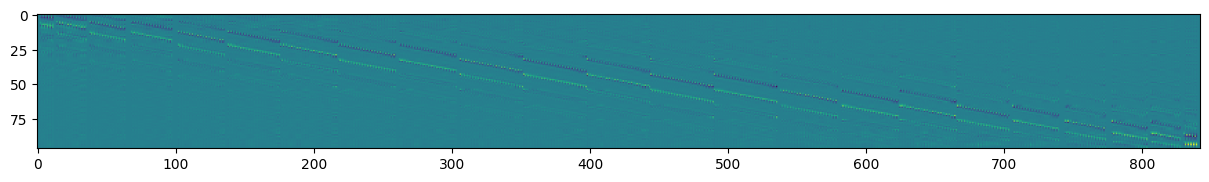

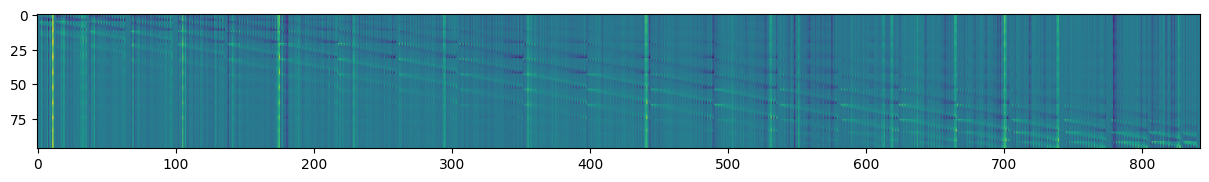

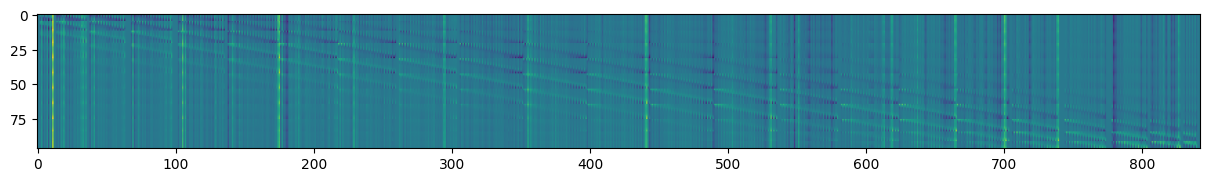

In [352]:
#inv_prev = np.load("../influ_nextwave.npy")
plt.figure(figsize=(15,9))
plt.imshow( infi_prev.T)
#plt.figure(figsize=(15,9))
#plt.imshow( influence_inv.T)
plt.figure(figsize=(15,9))
plt.imshow( C2 )
#plt.colorbar()

plt.figure(figsize=(15,9))
plt.imshow( C )

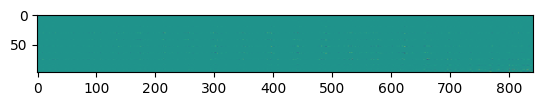

In [321]:
plt.imshow( (C2-C) )
#plt.colorbar()

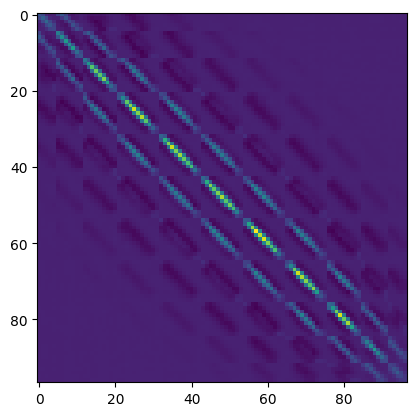

In [274]:
plt.imshow( DtD)

In [263]:
influence_inv.T.shape, C.shape

((97, 842), (97, 842))

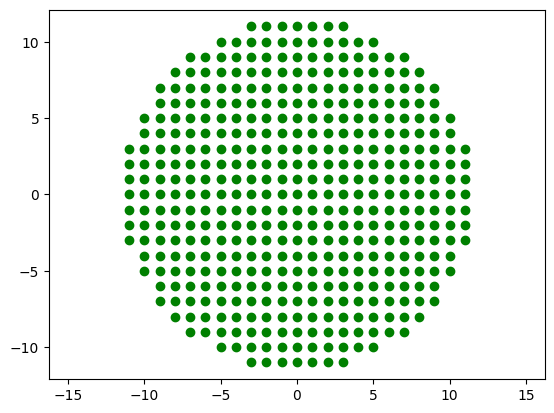

In [331]:
WRITE_OMITS=True
DO_PLOT=True

i,o,r=functions_grid.boxes_nrows(12, reference_x,reference_y,526,521,150,5.5,do_plot=DO_PLOT)

if WRITE_OMITS:
    fil=open("../omits.txt","wt")
    for o1 in o:
        fil.writelines("%d\n"%o1)
    fil.close()

In [29]:
class class_state1():
    def __init__(self):
        return

def do_ao1(GAIN=1.0,WRITE_MIRRORS=False,ZERO_FIRST=True,DO_PLOT=False,OVERRIDE_MEASURED=False,
           zerns_new=np.zeros(65),thresh=0.2,remove_TT=True):
    global state1
    
    mirs_new=np.zeros(97)
    if ZERO_FIRST:
        boxmem.write("mirror_voltages",mirs_new*0)
        shmir=np.zeros(97)
        time.sleep(0.25)
    else:
        shmir =shmem_item( buf_boxes, layoutb, 'mirror_voltages')[0:97]
    
    if DO_PLOT:
        print( shmir.max())
    
    centroid_x=boxmem.item('centroid_x')[0:num_boxes]
    centroid_y=boxmem.item('centroid_y')[0:num_boxes]
    reference_x=boxmem.item('reference_x')[0:num_boxes]
    reference_y=boxmem.item('reference_y')[0:num_boxes]

    if remove_TT:
        # This matches what is shown on the screen
        spot_displace_x =   centroid_x - reference_x  
        spot_displace_y =   centroid_y - reference_y
    
    if DO_PLOT:
        MULT=5
        plt.plot( (reference_x,reference_x+spot_displace_x*MULT),
                 (reference_y,reference_y+spot_displace_y*MULT), 'g-' )
        plt.plot( reference_x,reference_y, 'k.' )
        plt.gca().invert_yaxis()
        plt.gca().axis('equal')
    
    spot_displace_y -= np.nanmean( spot_displace_y )
    spot_displace_x -= np.nanmean( spot_displace_x )
    spot_displace_y = -spot_displace_y
    slope_all = np.concatenate( (spot_displace_y, spot_displace_x)) * (boxmem.item("pixel_um")) /( boxmem.item("focal_um")/1000)
    halfway = int( slope_all.shape[0]//2 )
    state1.halfway = halfway
    
    metric=boxmem.item("centroid_valid")[0:num_boxes]/100.0
    valids = (metric >= thresh)
    
    slope = np.concatenate( (spot_displace_y[valids], spot_displace_x[valids])) * (boxmem.item("pixel_um")) /( boxmem.item("focal_um")/1000)
    
    if OVERRIDE_MEASURED:
        # THIS WILL OVERRIDE the CURRENT readings with theoretical estimate from matrix inverse of best Mirror setting
        slope = -slopes_system.copy() #slope_uncor
        valids = (metric>=0) # Get everything

    print( '%d/%d' % (np.sum(valids), len(valids ) ), end=' ' )
    valid_stacked = np.concatenate( (valids, valids) )

    # First estimate the Zernikes
    coeff=np.matmul(zterms_full[:,valid_stacked],slope)
    
    #zernikes=coeff #[zernike_functions.CVS_to_OSA_map[0:len(coeff)]] # Return value will is OSA
    zernikes=coeff[zernike_functions.CVS_to_OSA_map[0:len(coeff)]] # Return value will is OSA

    if remove_TT:
        # Remove any tip/tilt
        zernikes[0] = 0
        zernikes[1] = 0
        zernikes += zerns_new
    
    slopes_est2 =np.matmul( zt_inv2, zernikes[zernike_functions.OSA_to_CVS_map[0:Z_TERMS]] )
    #slopes_est2 =np.matmul( zt_inv2, zernikes )
    slopes_est=slopes_est2

    state1.slopes_est = slopes_est2 
    # Convert slopes to displacement:
    # Conversion is done in the code
    state1.est_dx = slopes_est2[halfway:].copy() / (boxmem.item("pixel_um")) * ( boxmem.item("focal_um")/1000)
    state1.est_dy = -slopes_est2[:halfway].copy()/ (boxmem.item("pixel_um")) * ( boxmem.item("focal_um")/1000)
    
    boxmem.write("box_x_normalized", state1.est_dx) # ?
    boxmem.write("box_y_normalized", state1.est_dy) # ?
                 
    if DO_PLOT:
        plt.figure(figsize=(15,2))
        plt.bar( np.arange(len(zernikes[1:])), zernikes[1:] )
        
        plt.figure(figsize=(15,4))
        plt.plot( slopes_est2, label='full' )
        plt.plot( slope, '.', label='orig' )
        plt.plot( slopes_est, ls='--', label='partial' )
        plt.xlim(0-5, len(slope)+5 )
        plt.legend()
        
        plt.figure(figsize=(15,4))
        #plt.plot( mirs, 'o-' )
        #plt.plot( shmir, 's-' )
        plt.grid()
    
    
    if DO_PLOT:
        plt.plot( -mirs_new*GAIN, 'r--' )
    
    if (WRITE_MIRRORS):
        slope_reshape = np.vstack( (slopes_est2[halfway:],slopes_est2[:halfway]) ).T.flatten()
        mirs_new = np.matmul(influence_inv.T, slope_reshape/1000.0)
     
        mirs_now=boxmem.item("mirror_voltages")[0:97]
        boxmem.write("mirror_voltages",-mirs_new*GAIN+mirs_now)
        mem0.write("mode",[mem0.item("mode") | 0x20] )

state1=class_state1();
print((boxmem.item("pixel_um")) /( boxmem.item("focal_um") ) * 1000)

0.9821428571428572


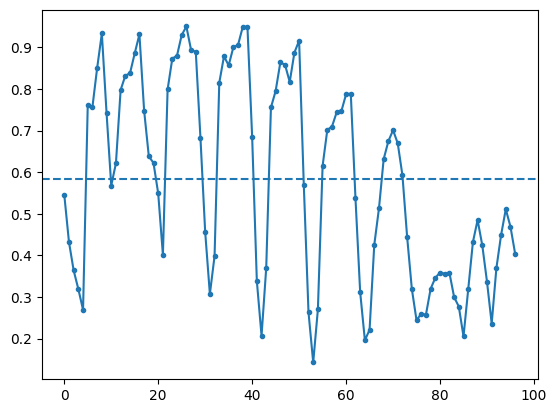

In [383]:
mirs_now=boxmem.item("mirror_voltages")[0:97]
plt.plot( mirs_now, '.-' )
plt.axhline( np.mean(mirs_now), ls='--')

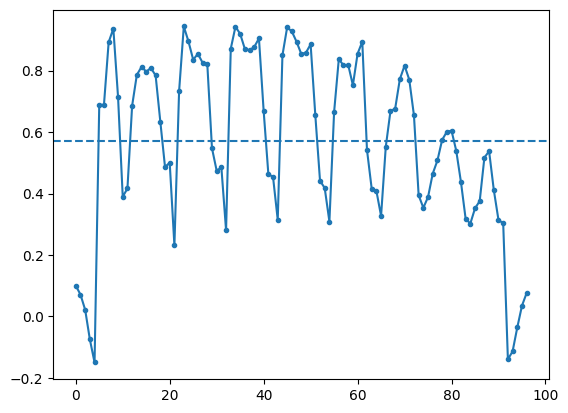

In [385]:
mirs_now=boxmem.item("mirror_voltages")[0:97]
plt.plot( mirs_now, '.-' )
plt.axhline( np.mean(mirs_now), ls='--')

In [378]:
# KAitlyn's Zs
GAIN=1.0
WRITE_MIRRORS=True
ZERO_FIRST=True
DO_PLOT=False
OVERRIDE_MEASURED=False

print( Z_k[2:5] )
Z_new=np.zeros(65)
Z_new= -Z_k
#Z_new[0:5] = [0,0,0,0.0,0]

if 1:
    do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED,zerns_new=Z_new,thresh=0.001)
    time.sleep(0.1)

[ 0.264171  4.924246 -0.241692]
287/421 

In [371]:
# Playing with calculations

GAIN=1.0
WRITE_MIRRORS=True
ZERO_FIRST=False
DO_PLOT=False
OVERRIDE_MEASURED=False

print( Z_k[2:5] )
Z_new=np.zeros(65)
Z_new=-Z_k*0

while 1:
    do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED,zerns_new=Z_new,thresh=0.001)
    time.sleep(0.1)

[ 0.264171  4.924246 -0.241692]
119/421 119/421 113/421 122/421 119/421 120/421 119/421 119/421 120/421 125/421 123/421 121/421 118/421 118/421 119/421 122/421 118/421 119/421 119/421 120/421 119/421 119/421 119/421 118/421 119/421 118/421 120/421 118/421 122/421 118/421 118/421 116/421 116/421 118/421 118/421 118/421 122/421 121/421 118/421 121/421 118/421 117/421 120/421 116/421 122/421 117/421 120/421 121/421 121/421 120/421 117/421 118/421 118/421 117/421 117/421 122/421 122/421 116/421 115/421 119/421 119/421 118/421 118/421 117/421 122/421 122/421 114/421 118/421 112/421 119/421 117/421 119/421 119/421 117/421 118/421 121/421 122/421 117/421 120/421 116/421 120/421 117/421 116/421 120/421 120/421 122/421 121/421 118/421 118/421 120/421 120/421 

KeyboardInterrupt: 

In [276]:
state1.est_dx[327], state1.est_dy[327], np.nanmean( state1.est_dy ), np.nanmean( state1.est_dx )

C:\Users\ao\AppData\Local\Temp\ipykernel_16736\4240402449.py:1: RuntimeWarning: Mean of empty slice
  state1.est_dx[327], state1.est_dy[327], np.nanmean( state1.est_dy ), np.nanmean( state1.est_dx )


(np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan))

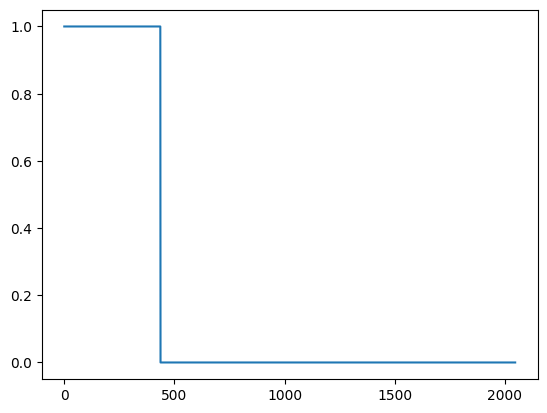

In [308]:
plt.plot( boxmem.item("centroid_valid") )

In [45]:
# One giant leap to KAitlyn's Zerns
GAIN=1.0
WRITE_MIRRORS=True
ZERO_FIRST=True
DO_PLOT=False
OVERRIDE_MEASURED=True

print( Z_k[2:5] )
Z_new=np.zeros(65)
Z_new[2] = -Z_k[2] -0.0
Z_new[3] = -Z_k[3] + 1.0*0
Z_new[4] = -Z_k[4] + 0.0
Z_new[11]=-0.5*1
#Z_new = -Z_k
do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED,zerns_new= 
       Z_new)
print()
print( Z_new[2:5] )

[ 0.264171  4.924246 -0.241692]
333/333 
[-0.264171 -4.924246  0.241692]


In [ ]:
# One giant leap to Model Eye
GAIN=1.0
WRITE_MIRRORS=True
ZERO_FIRST=True
DO_PLOT=False
OVERRIDE_MEASURED=True

Z_new=np.zeros(65)
Z_new[2:5]= -np.array( [0, 1,-1.1] )
# Z_new[11]=0.55
#Z_new = -Z_k
do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED,zerns_new= 
       Z_new)

In [749]:
print( Z_k[2:5] )

[ 0.264171  4.924246 -0.241692]


In [267]:
# One giant leap
GAIN=1.0
WRITE_MIRRORS=False
ZERO_FIRST=False
DO_PLOT=False
OVERRIDE_MEASURED=True

do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED)

421/421 

In [ ]:
# One giant leap
GAIN=0.0
WRITE_MIRRORS=False
ZERO_FIRST=False
DO_PLOT=False
OVERRIDE_MEASURED=False

do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED)

In [661]:
# One small step
GAIN=1.0
WRITE_MIRRORS=True
ZERO_FIRST=False
DO_PLOT=False
OVERRIDE_MEASURED=False

do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED,thresh=0.5)

328/333 

In [83]:
# Many little steps
GAIN=0.5
WRITE_MIRRORS=True
ZERO_FIRST=False
DO_PLOT=False
OVERRIDE_MEASURED=False

zerns_new=np.zeros(65)
#zerns_new[3] = 1.0
while True:
#if True:
    do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED, zerns_new,thresh=0.2)
    time.sleep(0.5)

0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 

KeyboardInterrupt: 

In [63]:
# Through focus
GAIN=1.0
WRITE_MIRRORS=True
ZERO_FIRST=False
DO_PLOT=False
OVERRIDE_MEASURED=False

do_ao1(GAIN,WRITE_MIRRORS,1,DO_PLOT,OVERRIDE_MEASURED)
time.sleep(0.5)

zerns_new=np.zeros(65)
for defocus in np.linspace(0,2.0,11):
    zerns_new[3] = defocus
    do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED, zerns_new)
    time.sleep(0.5)

0/333 0/333 0/333 0/333 0/333 0/333 0/333 

KeyboardInterrupt: 

In [76]:
# Alternate
GAIN=1.0
WRITE_MIRRORS=True
ZERO_FIRST=False # I think True is better
DO_PLOT=False
OVERRIDE_MEASURED=False

do_ao1(GAIN,WRITE_MIRRORS,1,DO_PLOT,OVERRIDE_MEASURED)
time.sleep(0.5)

while True:
    for defocus in [-1,0]:
        zerns_new[3] = defocus
        do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED, zerns_new)
        time.sleep(0.5)

0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 0/333 

KeyboardInterrupt: 

In [474]:
metric=boxmem.item("centroid_valid")[0:num_boxes]

(array([ 1.,  2.,  2.,  4.,  3.,  3.,  3.,  4.,  0.,  0.,  3.,  2.,  4.,
         1.,  2.,  0.,  4.,  2.,  1.,  3., 19., 22., 16., 23., 33., 32.,
        47., 77., 48., 28., 12.]),
 array([0.05      , 0.06887097, 0.08774194, 0.1066129 , 0.12548387,
        0.14435484, 0.16322581, 0.18209677, 0.20096774, 0.21983871,
        0.23870968, 0.25758065, 0.27645161, 0.29532258, 0.31419355,
        0.33306452, 0.35193548, 0.37080645, 0.38967742, 0.40854839,
        0.42741935, 0.44629032, 0.46516129, 0.48403226, 0.50290323,
        0.52177419, 0.54064516, 0.55951613, 0.5783871 , 0.59725806,
        0.61612903, 0.635     ]),
 <BarContainer object of 31 artists>)

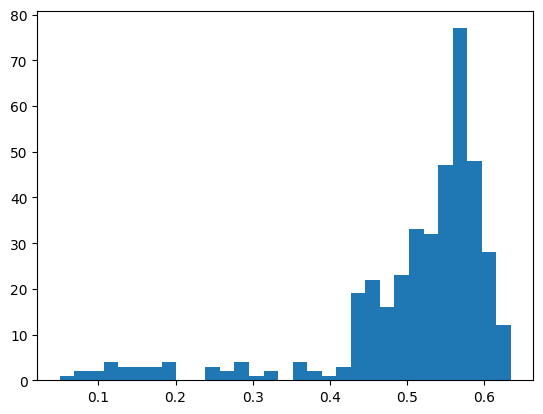

In [506]:
plt.hist( metric / 200.0, bins=31)

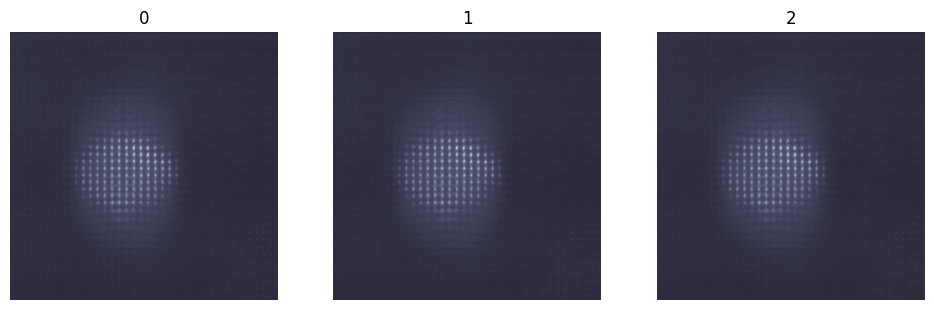

In [37]:


#Scanning
nframe=0
im1=log0.item("im",4231194*nframe)
im1=im1[0:1024*1024].reshape( (1024, 1024) )

plt.figure(figsize=(16,16))
for nframe in np.arange(0,3):
    plt.subplot(4,4,nframe+1)
    plt.imshow( im1, cmap='bone')
    plt.axis('off')
    plt.title(nframe)
  #  np.save("kaitlyn_good_spots_%d"%nframe,im1)

In [128]:
import joystickapi
import msvcrt
import time

print("start")

num = joystickapi.joyGetNumDevs()
ret, caps, startinfo = False, None, None
for id in range(num):
    ret, caps = joystickapi.joyGetDevCaps(id)
    if ret:
        print("gamepad detected: " + caps.szPname)
        ret, startinfo = joystickapi.joyGetPosEx(id)
        break
else:
    print("no gamepad detected")

run = ret
value = 2
while run:
    time.sleep(0.50)
    if msvcrt.kbhit() and msvcrt.getch() == chr(27).encode(): # detect ESC
        run = False

    ret, info = joystickapi.joyGetPosEx(id)
    if ret:
        btns = [(1 << i) & info.dwButtons != 0 for i in range(caps.wNumButtons)]
        axisXYZ = [info.dwXpos-startinfo.dwXpos, info.dwYpos-startinfo.dwYpos, info.dwZpos-startinfo.dwZpos]
        axisRUV = [info.dwRpos-startinfo.dwRpos, info.dwUpos-startinfo.dwUpos, info.dwVpos-startinfo.dwVpos]
        if info.dwButtons:
            if btns[1]:
                break
        #        time.sleep(0.25)
                # One giant leap to KAitlyn's Zerns
        #        GAIN=1.0
        #        WRITE_MIRRORS=True
        #        ZERO_FIRST=True
        #        DO_PLOT=False
        #        OVERRIDE_MEASURED=True
                
                #Z_new=np.zeros(65)
               # Z_new[2:5]=-Z_k[2:5]
                # Z_new[11]=0.55
                #Z_new = -Z_k
                #do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED,zerns_new= 
                #       Z_new)
                

        #if any([abs(v) > 10 for v in axisXYZ]):
        
            #print("axis:", axisXYZ)
        if any([abs(v) > 50 for v in axisRUV]):
            delta = float(axisRUV[0])/32769 # Scale to -1 to +1
            value = delta * 8   # Now it's -8 to 8... (um)
            #print("roation axis:", value)

            # One giant leap to KAitlyn's Zerns
            GAIN=1.0
            WRITE_MIRRORS=True
            ZERO_FIRST=True
            DO_PLOT=False
            OVERRIDE_MEASURED=True
                
            Z_new=np.zeros(65)
            Z_new[2]=-Z_k[2]
            Z_new[3]=-value
            Z_new[4]=-Z_k[4]
            #Z_new[11]=0.55
            #Z_new = -Z_k
            do_ao1(GAIN,WRITE_MIRRORS,ZERO_FIRST,DO_PLOT,OVERRIDE_MEASURED,zerns_new= 
                   Z_new)
            print(value,end= ' ')
print('\n', value,end= ' ')            
print("end")


start
gamepad detected: Microsoft PC-joystick driver
333/333 0.41038786658122006 333/333 4.697610546553145 333/333 4.663431902102597 333/333 4.663431902102597 333/333 4.668314565595533 333/333 4.668314565595533 333/333 4.673197229088467 333/333 4.678079892581403 333/333 5.200524886325491 333/333 5.420244743507584 333/333 5.635081937196741 
 5.635081937196741 end
